In [9]:
import torch
import numpy as np
import anndata as ad
import scanpy as sc
import os
import pickle
from pathlib import Path

from data.dataset import CondFMDataset
from data.splitters import (
    SplitConfig,
    apply_holdout_masks,
    load_manifest_json,
    make_split_artifacts,
    validate_no_leakage,
)
from models.autoencoder import NBAutoEncoder
from models.flow import CondFlow, ConditionEncoder
from training.losses import FlowMatchingMSELoss, LossComposer
from training.trainer_flow_matching import train_flow_matching


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
config = SplitConfig()
artifacts = make_split_artifacts(config)

subsample_h5ad_path = Path(f"sciplex_subsample_{artifacts.tag}.h5ad")
ode_metadata_path = Path(f"sciplex_ode_metadata_{artifacts.tag}.pkl")
ae_space_path = Path(f"sciplex_ae_space_{artifacts.tag}.pkl")
fm_nbae_model_path = Path(f"sciplex_fm_nbae_model_{artifacts.tag}.pt")
fm_nbae_metadata_path = Path(f"sciplex_fm_nbae_metadata_{artifacts.tag}.pkl")

required = {
    "subsample_h5ad": subsample_h5ad_path,
    "holdout_manifest": artifacts.holdout_json_path,
    "ode_metadata": ode_metadata_path,
    "ae_space": ae_space_path,
}
missing = [f"{name}: {path}" for name, path in required.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required artifacts for FM_NBAE training:\n  - " + "\n  - ".join(missing))

adata = ad.read_h5ad(subsample_h5ad_path)
manifest = load_manifest_json(artifacts.holdout_json_path)

with open(ode_metadata_path, "rb") as f:
    ode_meta = pickle.load(f)

with open(ae_space_path, "rb") as f:
    space = pickle.load(f)

ae_hvg_names = space.hvg_names
LATENT_DIM = 128
ae_model = space.ae_model.to(device)
ae_model.eval()
n_genes = len(ae_hvg_names)
print(f"Using split tag: {artifacts.tag}")
print(f"loaded NB AE from SpaceManager: {n_genes} genes -> {LATENT_DIM}d latent")


Using split tag: strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle
loaded NB AE from SpaceManager: 2000 genes -> 128d latent


In [12]:
SEED = config.seed
test_cell_type = config.test_cell_type

masks = apply_holdout_masks(adata, manifest)
validate_no_leakage(adata, masks, product_name_col="product_name")

is_held_out = masks["is_held_out"]
is_pert_any = masks["is_pert_any"]
is_pert_train = masks["is_pert_train"]

held_out_products = manifest["selected_holdout_product_names"]
print(f"held-out products for {test_cell_type}: {held_out_products}")
print(
    f"Train cells: {masks['is_train'].sum()}, "
    f"Held-out perturbed cells: {is_held_out.sum()}, "
    f"Train perturbed cells: {is_pert_train.sum()}"
)

adata_train = adata[masks["is_train"]].copy()


held-out products for K562: ['AG-490 (Tyrphostin B42)', 'AMG-900', 'AR-42', 'AZ 960', 'AZD1480', 'Alendronate sodium trihydrate', 'Alvespimycin (17-DMAG) HCl', 'Anacardic Acid', 'Andarine', 'Aurora A Inhibitor I', 'Avagacestat (BMS-708163)', 'BMS-911543', 'Baricitinib (LY3009104, INCB028050)', 'CEP-33779', 'CYC116', 'Cediranib (AZD2171)', 'Celecoxib', 'Crizotinib (PF-02341066)', 'Dacinostat (LAQ824)', 'Danusertib (PHA-739358)', 'Daphnetin', 'Dasatinib', 'Decitabine', 'Disulfiram ', 'Divalproex Sodium', 'ENMD-2076', 'Ellagic acid', 'Entacapone', 'Enzastaurin (LY317615)', 'FLLL32', 'Fedratinib (SAR302503, TG101348)', 'Filgotinib (GLPG0634)', 'Flavopiridol HCl', 'Fluorouracil (5-Fluoracil, 5-FU)', 'G007-LK', 'GSK-LSD1 2HCl', 'GSK1070916', 'Gandotinib (LY2784544)', 'Glesatinib?(MGCD265)', 'INO-1001 (3-Aminobenzamide)', 'ITSA-1 (ITSA1)', 'Iniparib (BSI-201)', 'Ivosidenib (AG-120)', 'Lenalidomide (CC-5013)', 'Linifanib (ABT-869)', 'Lomustine ', 'Luminespib (AUY-922, NVP-AUY922)', 'M344', 'MK

In [13]:
# reuse vocab from ODE training so both models share identical index mappings
pert_to_idx = ode_meta["pert_to_idx"]
rep_to_idx = ode_meta["rep_to_idx"]
ct_to_idx = ode_meta["ct_to_idx"]

pert_ids = torch.tensor([pert_to_idx[p] for p in adata_train.obs["product_dose"]], dtype=torch.long)
rep_ids = torch.tensor([rep_to_idx[r] for r in adata_train.obs["replicate"]], dtype=torch.long)
ct_ids = torch.tensor([ct_to_idx[ct] for ct in adata_train.obs["cell_type"]], dtype=torch.long)

condition_batch = {
    "perturbations": pert_ids,
    "perturbation_covariates": {},
    "sample_covariates": {
        "replicate": rep_ids,
        "cell_type": ct_ids,
    },
}

# encode training data into AE latent space using AE's own HVG set
adata_train_hvg = adata_train[:, ae_hvg_names].copy()

# log1p-normalize (same normalization the AE encoder expects)
X_raw = adata_train_hvg.X.toarray() if hasattr(adata_train_hvg.X, "toarray") else adata_train_hvg.X
X_raw_t = torch.tensor(X_raw, dtype=torch.float32, device=device)
lib_size = X_raw_t.sum(dim=1, keepdim=True).clamp(min=1)
x_log_norm = torch.log1p(X_raw_t / lib_size * 1e4)

# encode in chunks to avoid OOM
chunk_size = 5000
z_parts = []
with torch.no_grad():
    for i in range(0, x_log_norm.shape[0], chunk_size):
        z_parts.append(ae_model.encode(x_log_norm[i : i + chunk_size]).cpu())
z_all = torch.cat(z_parts, dim=0).numpy()
print(f"Encoded {z_all.shape[0]} cells to latent dim {z_all.shape[1]}")

# create a synthetic AnnData with latent vectors as .X
adata_latent = ad.AnnData(
    X=z_all,
    obs=adata_train.obs.copy(),
)

ds = CondFMDataset(
    adata_latent, condition_batch, control_col="vehicle", control_value=1.0, use_pca=False, use_norm=False
)

Encoded 51147 cells to latent dim 128


In [14]:
covariate_dicts = ode_meta["covariate_dicts"]

cond_enc = ConditionEncoder(covariate_dicts=covariate_dicts, embedding_dim=64, condition_dim=128)
model = CondFlow(
    input_dim=LATENT_DIM, output_dim=LATENT_DIM, hidden_dim=256, hidden_layers=4, cond_encoder=cond_enc
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_composer = LossComposer({"fm_mse": FlowMatchingMSELoss()}, {"fm_mse": 1.0})

history = train_flow_matching(
    model=model,
    dataset=ds,
    loss_composer=loss_composer,
    optimizer=optimizer,
    epochs=100,
    batch_size=2048,
    device=device,
    use_sampler=True,
    steps_per_epoch=100,
)

torch.save(model.state_dict(), fm_nbae_model_path)

metadata = {
    "split_tag": artifacts.tag,
    "holdout_manifest_path": str(artifacts.holdout_json_path),
    "subsample_h5ad_path": str(subsample_h5ad_path),
    "pert_to_idx": pert_to_idx,
    "rep_to_idx": rep_to_idx,
    "ct_to_idx": ct_to_idx,
    "covariate_dicts": covariate_dicts,
    "hvg_names": ae_hvg_names,
    "latent_dim": LATENT_DIM,
    "mean": ds.mean,
    "std": ds.std,
}
with open(fm_nbae_metadata_path, "wb") as f:
    pickle.dump(metadata, f)

print(f"Saved FM_NBAE model to {fm_nbae_model_path}")
print(f"Saved FM_NBAE metadata to {fm_nbae_metadata_path}")


training flow matching model on device: cuda


Epoch 1/100: 100%|██████████| 100/100 [00:00<00:00, 169.97it/s]


epoch 1/100 - train Loss: 190.8897


Epoch 2/100: 100%|██████████| 100/100 [00:00<00:00, 142.07it/s]


epoch 2/100 - train Loss: 62.3554


...

epoch 98/100 - train Loss: 6.5304


Epoch 99/100: 100%|██████████| 100/100 [00:00<00:00, 168.69it/s]


epoch 99/100 - train Loss: 5.8697


Epoch 100/100: 100%|██████████| 100/100 [00:00<00:00, 180.64it/s]

epoch 100/100 - train Loss: 5.1810
Saved FM_NBAE model to sciplex_fm_nbae_model_strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle.pt
Saved FM_NBAE metadata to sciplex_fm_nbae_metadata_strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle.pkl


Text(0.5, 1.0, 'fm train loss')

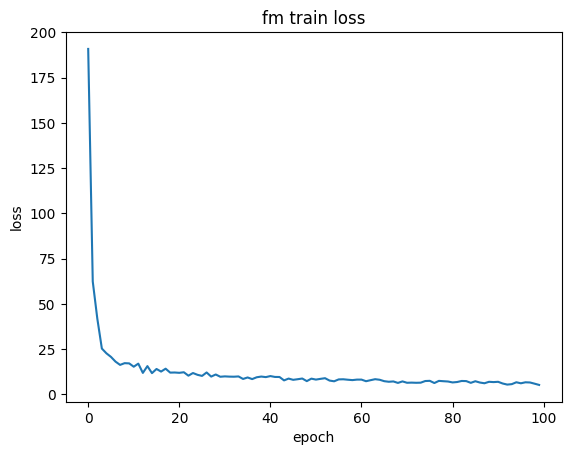

In [15]:
# plot training hist
import matplotlib.pyplot as plt

plt.plot(history["train_loss"], label="train loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("fm train loss")

In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from models.flow import sample_ode

# --- pick a held-out perturbation for K562 ---
held_out_dose_strs = sorted(
    adata.obs.loc[is_held_out & (adata.obs["cell_type"] == test_cell_type), "product_dose"].unique()
)
example_pd = next(pd for pd in held_out_dose_strs if pd in pert_to_idx)
print(f"Example perturbation: {example_pd}")

# --- get K562 control cells in latent space ---
is_ctrl_k562 = (adata.obs["vehicle"] == 1) & (adata.obs["cell_type"] == test_cell_type)
adata_ctrl_hvg = adata[is_ctrl_k562, ae_hvg_names].copy()

X_ctrl_raw = adata_ctrl_hvg.X.toarray() if hasattr(adata_ctrl_hvg.X, "toarray") else adata_ctrl_hvg.X
X_ctrl_t = torch.tensor(X_ctrl_raw, dtype=torch.float32, device=device)
ctrl_lib = X_ctrl_t.sum(dim=1).clamp(min=1)  # 1D for decode
x_ctrl_log = torch.log1p(X_ctrl_t / ctrl_lib.unsqueeze(-1) * 1e4)

# observed control log1p
ctrl_lib_np = X_ctrl_raw.sum(axis=1, keepdims=True)
log1p_ctrl_obs = np.log1p(X_ctrl_raw / np.maximum(ctrl_lib_np, 1) * 1e4)

with torch.no_grad():
    z_ctrl = ae_model.encode(x_ctrl_log)

n_ctrl = z_ctrl.shape[0]
ctrl_obs_df = adata[is_ctrl_k562].obs
cond_ctrl = {
    "perturbations": torch.full((n_ctrl,), pert_to_idx[example_pd], dtype=torch.long),
    "perturbation_covariates": {},
    "sample_covariates": {
        "replicate": torch.tensor([rep_to_idx[r] for r in ctrl_obs_df["replicate"]], dtype=torch.long),
        "cell_type": torch.tensor([ct_to_idx[c] for c in ctrl_obs_df["cell_type"]], dtype=torch.long),
    },
}

model.eval()
with torch.no_grad():
    z_pred = sample_ode(model, z_ctrl, cond_ctrl, method="rk4", time=1.0)


# --- decode by sampling from NB (produces real zeros) ---
def decode_nb_sample(ae, z, lib_size):
    """Decode latent z to log1p-normalized expression by sampling from the NB distribution."""
    with torch.no_grad():
        mu, theta = ae.decode(z, lib_size)
        p = mu / (mu + theta + 1e-8)
        nb_counts = torch.distributions.NegativeBinomial(total_count=theta, probs=p).sample()
        sample_lib = nb_counts.sum(dim=-1, keepdim=True).clamp(min=1)
        return torch.log1p(nb_counts / sample_lib * 1e4).cpu().numpy()


log1p_ctrl_dec = decode_nb_sample(ae_model, z_ctrl, ctrl_lib)
log1p_pred = decode_nb_sample(ae_model, z_pred, ctrl_lib)

# --- ground truth perturbed cells ---
is_gt = is_held_out & (adata.obs["product_dose"] == example_pd)
adata_gt_hvg = adata[is_gt, ae_hvg_names].copy()
X_gt_raw = adata_gt_hvg.X.toarray() if hasattr(adata_gt_hvg.X, "toarray") else adata_gt_hvg.X
gt_lib_np = X_gt_raw.sum(axis=1, keepdims=True)
log1p_gt = np.log1p(X_gt_raw / np.maximum(gt_lib_np, 1) * 1e4)

# encode then decode ground truth perturbed cells (round-trip check)
X_gt_t = torch.tensor(X_gt_raw, dtype=torch.float32, device=device)
gt_lib_t = X_gt_t.sum(dim=1).clamp(min=1)
x_gt_log = torch.log1p(X_gt_t / gt_lib_t.unsqueeze(-1) * 1e4)
with torch.no_grad():
    z_gt = ae_model.encode(x_gt_log)
log1p_gt_dec = decode_nb_sample(ae_model, z_gt, gt_lib_t)

# --- pick top variable genes from OBSERVED data ---
combined_obs = np.concatenate([log1p_ctrl_obs, log1p_gt], axis=0)
gene_var = combined_obs.var(axis=0)
top_idx = np.argsort(gene_var)[::-1][:10]
gene_names = list(np.array(ae_hvg_names)[top_idx])

TRACES = [
    ("Control (observed)", log1p_ctrl_obs, "#66CCEE"),
    ("Control (decoded)", log1p_ctrl_dec, "#4477AA"),
    ("Perturbed (observed)", log1p_gt, "#228833"),
    ("Perturbed (decoded)", log1p_gt_dec, "#AACC44"),
    ("Predicted (decoded)", log1p_pred, "#EE6677"),
]
BINS = 40
NCOLS = 5
NROWS = 2

fig = make_subplots(
    rows=NROWS,
    cols=NCOLS,
    subplot_titles=gene_names,
    horizontal_spacing=0.04,
    vertical_spacing=0.14,
)

for plot_i, (g_idx, g_name) in enumerate(zip(top_idx, gene_names)):
    row = plot_i // NCOLS + 1
    col = plot_i % NCOLS + 1
    show_legend = plot_i == 0

    all_vals = np.concatenate([data[:, g_idx] for _, data, _ in TRACES])
    bin_edges = np.linspace(0, all_vals.max() + 0.1, BINS + 1)

    for label, data, color in TRACES:
        counts, edges = np.histogram(data[:, g_idx], bins=bin_edges, density=True)
        fig.add_trace(
            go.Bar(
                x=edges[:-1],
                y=counts,
                width=np.diff(edges),
                name=label,
                legendgroup=label,
                showlegend=show_legend,
                marker_color=color,
                opacity=0.55,
                offsetgroup=label,
            ),
            row=row,
            col=col,
        )

fig.update_layout(
    barmode="overlay",
    title_text=f"Decoded distributions — {example_pd} — top 10 variable HVGs",
    title_font_size=14,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.06,
        xanchor="center",
        x=0.5,
        font_size=11,
    ),
    height=800,
    width=2400,
    bargap=0,
)
fig.update_xaxes(title_text="log1p expr", title_font_size=9, tickfont_size=8)
fig.update_yaxes(title_text="density", title_font_size=9, tickfont_size=8)
fig.show()

Example perturbation: AG-490 (Tyrphostin B42)_10
